# Walmart Store Sales Forecasting
## Feature Engineering + Cleaning + Selection Pipeline


**Pipeline order**
- Setup & Data Loading
- Merge & Basic Preprocessing
- Train / Val / Test Split  ← first
- Outlier Detection & Target Cleaning  ← train only
- Feature Engineering  ← statistics computed from train only
- Feature Cleaning
- Feature Selection

## Setup & Data Loading

In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/train.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/sampleSubmission.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/stores.csv
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/features.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/test.csv.zip


In [4]:

import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/train.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/sampleSubmission.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/stores.csv
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/features.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/test.csv.zip


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:.4f}'.format)
np.random.seed(42)

BASE = '/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/'
train    = pd.read_csv(BASE + 'train.csv.zip')
test     = pd.read_csv(BASE + 'test.csv.zip')
stores   = pd.read_csv(BASE + 'stores.csv')
features = pd.read_csv(BASE + 'features.csv.zip')

print(f"train    : {train.shape}")
print(f"test     : {test.shape}")
print(f"stores   : {stores.shape}")
print(f"features : {features.shape}")
train.head()

train    : (421570, 5)
test     : (115064, 4)
stores   : (45, 3)
features : (8190, 12)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.5000,False
1,1,1,2010-02-12,46039.4900,True
2,1,1,2010-02-19,41595.5500,False
3,1,1,2010-02-26,19403.5400,False
4,1,1,2010-03-05,21827.9000,False


## Merge & Basic Preprocessing

In [6]:
train['is_train'] = 1
test['is_train']  = 0
test['Weekly_Sales'] = np.nan

df = pd.concat([train, test], axis=0, ignore_index=True)
df = df.merge(stores,   on='Store',                        how='left')
df = df.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

print(f"Combined shape: {df.shape}")
missing = df.isnull().sum()
print("\nMissing values (raw):")
print(missing[missing > 0])

Combined shape: (536634, 17)

Missing values (raw):
Weekly_Sales    115064
MarkDown1       271038
MarkDown2       338949
MarkDown3       294308
MarkDown4       299491
MarkDown5       270138
CPI              38162
Unemployment     38162
dtype: int64


## Train / Val / Test Split

In [7]:
max_train_date = df.loc[df['is_train'] == 1, 'Date'].max()
VAL_WEEKS  = 8
val_cutoff = max_train_date - pd.Timedelta(weeks=VAL_WEEKS)

tr_mask  = (df['is_train'] == 1) & (df['Date'] <= val_cutoff)
val_mask = (df['is_train'] == 1) & (df['Date'] >  val_cutoff)
te_mask  = df['is_train'] == 0

print(f"Train : {tr_mask.sum():,} rows  ({df.loc[tr_mask,  'Date'].min().date()} → {df.loc[tr_mask,  'Date'].max().date()})")
print(f"Val   : {val_mask.sum():,} rows  ({df.loc[val_mask, 'Date'].min().date()} → {df.loc[val_mask, 'Date'].max().date()})")
print(f"Test  : {te_mask.sum():,} rows")

Train : 397,841 rows  (2010-02-05 → 2012-08-31)
Val   : 23,729 rows  (2012-09-07 → 2012-10-26)
Test  : 115,064 rows


## Outlier Detection & Target Cleaning


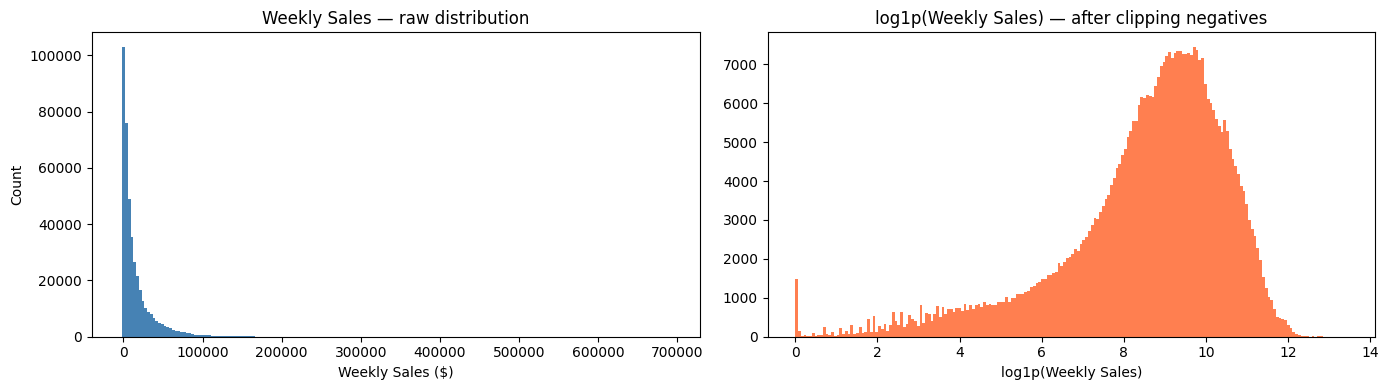

Negative sales rows : 1,285  (0.30%)
Zero sales rows     : 73  (0.02%)
Min: -4,989   Max: 693,099


In [8]:
# Visualise the target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
train_raw = df[df['is_train'] == 1]['Weekly_Sales']
axes[0].hist(train_raw, bins=200, color='steelblue', edgecolor='none')
axes[0].set_title('Weekly Sales — raw distribution')
axes[0].set_xlabel('Weekly Sales ($)')
axes[0].set_ylabel('Count')
axes[1].hist(np.log1p(train_raw.clip(lower=0)), bins=200, color='coral', edgecolor='none')
axes[1].set_title('log1p(Weekly Sales) — after clipping negatives')
axes[1].set_xlabel('log1p(Weekly Sales)')
plt.tight_layout()
plt.show()

print(f"Negative sales rows : {(train_raw < 0).sum():,}  ({100*(train_raw < 0).mean():.2f}%)")
print(f"Zero sales rows     : {(train_raw == 0).sum():,}  ({100*(train_raw == 0).mean():.2f}%)")
print(f"Min: {train_raw.min():,.0f}   Max: {train_raw.max():,.0f}")

In [9]:
def iqr_bounds(s, k=3.0):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

lo_map = (
    df[tr_mask]
    .groupby(['Store', 'Dept'])['Weekly_Sales']
    .apply(lambda s: iqr_bounds(s)[0])
    .rename('iqr_lo')
)
hi_map = (
    df[tr_mask]
    .groupby(['Store', 'Dept'])['Weekly_Sales']
    .apply(lambda s: iqr_bounds(s)[1])
    .rename('iqr_hi')
)

df['iqr_lo'] = df.set_index(['Store', 'Dept']).index.map(lo_map)
df['iqr_hi'] = df.set_index(['Store', 'Dept']).index.map(hi_map)

df['is_outlier'] = 0
df.loc[tr_mask & (df['Weekly_Sales'] < df['iqr_lo']), 'is_outlier'] = -1
df.loc[tr_mask & (df['Weekly_Sales'] > df['iqr_hi']), 'is_outlier'] =  1

n_out = (df['is_outlier'] != 0).sum()
print(f"Outlier rows flagged: {n_out:,}  ({100*n_out/tr_mask.sum():.2f}% of train)")

Outlier rows flagged: 6,981  (1.75% of train)


In [10]:
df['Weekly_Sales_raw'] = df['Weekly_Sales'].copy()

df.loc[tr_mask, 'Weekly_Sales'] = df.loc[tr_mask, 'Weekly_Sales'].clip(
    lower=df.loc[tr_mask, 'iqr_lo'],
    upper=df.loc[tr_mask, 'iqr_hi']
)

p01 = df.loc[tr_mask, 'Weekly_Sales'].quantile(0.001)
df.loc[tr_mask, 'Weekly_Sales'] = df.loc[tr_mask, 'Weekly_Sales'].clip(lower=p01)

print(f"Post-clean range: {df.loc[tr_mask,'Weekly_Sales'].min():,.1f}  to  {df.loc[tr_mask,'Weekly_Sales'].max():,.1f}")
df.drop(columns=['iqr_lo','iqr_hi'], inplace=True)

Post-clean range: -25.9  to  283,843.0


## Date / Calendar Features

Cyclical sin/cos encoding keeps week 52 and week 1 numerically adjacent.

In [11]:
df['Year']        = df['Date'].dt.year
df['Month']       = df['Date'].dt.month
df['Week']        = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter']     = df['Date'].dt.quarter
df['WeekOfMonth'] = (df['Date'].dt.day - 1) // 7 + 1

df['Month_sin']   = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos']   = np.cos(2 * np.pi * df['Month'] / 12)
df['Week_sin']    = np.sin(2 * np.pi * df['Week']  / 52)
df['Week_cos']    = np.cos(2 * np.pi * df['Week']  / 52)

t0 = df['Date'].min()
df['Weeks_elapsed'] = ((df['Date'] - t0).dt.days / 7).astype(int)

print("Date features added.")
df[['Date','Year','Month','Week','Quarter','WeekOfMonth','Week_sin','Week_cos']].head(6)

Date features added.


,Date,Year,Month,Week,Quarter,WeekOfMonth,Week_sin,Week_cos
0,2010-02-05,2010,2,5,1,1,0.5681,0.8230
1,2010-02-12,2010,2,6,1,2,0.6631,0.7485
2,2010-02-19,2010,2,7,1,3,0.7485,0.6631
3,2010-02-26,2010,2,8,1,4,0.8230,0.5681
4,2010-03-05,2010,3,9,1,1,0.8855,0.4647
5,2010-03-12,2010,3,10,1,2,0.9350,0.3546


## Holiday Proximity Features

Holiday weeks are weighted **5×** in WMAE. Dates are fixed calendar facts — no leakage risk.

In [12]:
HOLIDAYS = {
    'SuperBowl':    ['2010-02-12','2011-02-11','2012-02-10','2013-02-08'],
    'LaborDay':     ['2010-09-10','2011-09-09','2012-09-07','2013-09-06'],
    'Thanksgiving': ['2010-11-26','2011-11-25','2012-11-23','2013-11-29'],
    'Christmas':    ['2010-12-31','2011-12-30','2012-12-28','2013-12-27'],
}

for name, dates in HOLIDAYS.items():
    hol_dates = pd.to_datetime(dates)

    def signed_days(d, hd=hol_dates):
        return min([(d - h).days for h in hd], key=abs)

    df[f'Days_to_{name}']  = df['Date'].apply(signed_days)
    df[f'Weeks_to_{name}'] = df[f'Days_to_{name}'] // 7
    df[f'Is_{name}']       = (df[f'Days_to_{name}'] == 0).astype(int)
    df[f'Pre_{name}_2w']   = ((df[f'Days_to_{name}'] >= -14) & (df[f'Days_to_{name}'] < 0)).astype(int)
    df[f'Post_{name}_1w']  = ((df[f'Days_to_{name}'] > 0) & (df[f'Days_to_{name}'] <= 7)).astype(int)

# Additional retail events
df['Is_BackToSchool']   = df['Week'].between(31, 35).astype(int)
df['Is_PreHalloween']   = df['Week'].between(41, 43).astype(int)
df['Is_ValentinesWeek'] = df['Week'].between(6, 7).astype(int)

def easter_date(year):
    a = year % 19; b = year // 100; c = year % 100
    d = b // 4;    e = b % 4;       f = (b + 8) // 25
    g = (b - f + 1) // 3
    h = (19*a + b - d - g + 15) % 30
    i = c // 4;    k = c % 4
    l = (32 + 2*e + 2*i - h - k) % 7
    m = (a + 11*h + 22*l) // 451
    month = (h + l - 7*m + 114) // 31
    day   = ((h + l - 7*m + 114) % 31) + 1
    return pd.Timestamp(year=year, month=month, day=day)

easter_dates = [easter_date(y) for y in range(2010, 2014)]
df['Days_to_Easter'] = df['Date'].apply(lambda d: min(abs((d - e).days) for e in easter_dates))
df['Is_EasterWeek']  = (df['Days_to_Easter'] <= 7).astype(int)

hcols = [c for c in df.columns if any(x in c for x in ['Days_to','Weeks_to','Is_','Pre_','Post_'])]
print(f"Holiday/event features: {len(hcols)}")

Holiday/event features: 25


## Lag Features


In [13]:
g = df.groupby(['Store', 'Dept'])['Weekly_Sales']

for w in [1, 2, 3, 4, 8, 13, 26, 39, 51, 52, 53, 56, 104]:
    df[f'lag_{w}w'] = g.shift(w)

roll4       = g.shift(1).groupby([df['Store'], df['Dept']]).transform(
    lambda x: x.rolling(4, min_periods=1).mean())
roll4_ly    = g.shift(53).groupby([df['Store'], df['Dept']]).transform(
    lambda x: x.rolling(4, min_periods=1).mean())
df['yoy_ratio_4w'] = roll4 / (roll4_ly + 1e-8)

lag_cols = [c for c in df.columns if c.startswith('lag_')]
print(f"Lag features ({len(lag_cols)}): {lag_cols}")

Lag features (13): ['lag_1w', 'lag_2w', 'lag_3w', 'lag_4w', 'lag_8w', 'lag_13w', 'lag_26w', 'lag_39w', 'lag_51w', 'lag_52w', 'lag_53w', 'lag_56w', 'lag_104w']


## Rolling Window Statistics

Shifted by 1 before rolling to prevent look-ahead leakage.

In [14]:
shifted = df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1)

for window in [4, 8, 13, 26, 52]:
    base = shifted.groupby([df['Store'], df['Dept']])
    df[f'roll_mean_{window}w'] = base.transform(lambda x: x.rolling(window, min_periods=1).mean())
    df[f'roll_std_{window}w']  = base.transform(lambda x: x.rolling(window, min_periods=1).std())
    df[f'roll_max_{window}w']  = base.transform(lambda x: x.rolling(window, min_periods=1).max())
    df[f'roll_min_{window}w']  = base.transform(lambda x: x.rolling(window, min_periods=1).min())

df['roll_cv_13w']    = df['roll_std_13w']  / (df['roll_mean_13w']  + 1e-8)
df['momentum_4_26']  = df['roll_mean_4w']  / (df['roll_mean_26w']  + 1e-8)
df['momentum_13_52'] = df['roll_mean_13w'] / (df['roll_mean_52w']  + 1e-8)

roll_cols = [c for c in df.columns if c.startswith('roll_') or 'momentum' in c]
print(f"Rolling features: {len(roll_cols)}")

Rolling features: 23


## Markdown Features

NaN means no markdown event — distinct from a zero-dollar markdown.

In [15]:
MD_COLS = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']

for col in MD_COLS:
    df[f'{col}_present'] = df[col].notna().astype(int)

for col in MD_COLS:
    df[col] = df[col].fillna(0)

df['MD_total']        = df[MD_COLS].sum(axis=1)
df['MD_count']        = df[[f'{c}_present' for c in MD_COLS]].sum(axis=1)
df['MD_max']          = df[MD_COLS].max(axis=1)
df['MD_nonzero_mean'] = df[MD_COLS].replace(0, np.nan).mean(axis=1).fillna(0)
df['MD_total_log']    = np.log1p(df['MD_total'].clip(lower=0))

df['MD_x_holiday']      = df['MD_total'] * df['IsHoliday'].astype(int)
df['MD_x_thanksgiving'] = df['MD_total'] * df['Is_Thanksgiving']
df['MD_x_christmas']    = df['MD_total'] * df['Is_Christmas']

md_new = [c for c in df.columns if 'MD_' in c and c not in MD_COLS]
print(f"Markdown features ({len(md_new)}): {md_new}")

Markdown features (8): ['MD_total', 'MD_count', 'MD_max', 'MD_nonzero_mean', 'MD_total_log', 'MD_x_holiday', 'MD_x_thanksgiving', 'MD_x_christmas']


## Store / Department Target Encoding

All aggregates computed from **train rows only** (`tr_mask`), then mapped to val and test.

In [16]:
tr_df = df[tr_mask].copy()

# Fixed target encoding using expanding shifted means to avoid leakage
g_store = df.groupby('Store')['Weekly_Sales']
df['store_mean'] = g_store.transform(lambda x: x.shift(1).expanding().mean())

g_dept = df.groupby('Dept')['Weekly_Sales']
df['dept_mean'] = g_dept.transform(lambda x: x.shift(1).expanding().mean())

g_type = df.groupby('Type')['Weekly_Sales']
df['type_mean'] = g_type.transform(lambda x: x.shift(1).expanding().mean())

g_sd = df.groupby(['Store', 'Dept'])['Weekly_Sales']
df['store_dept_mean'] = g_sd.transform(lambda x: x.shift(1).expanding().mean())
df['store_dept_median'] = g_sd.transform(lambda x: x.shift(1).expanding().median())
df['store_dept_std'] = g_sd.transform(lambda x: x.shift(1).expanding().std())

g_dw = df.groupby(['Dept', 'Week'])['Weekly_Sales']
df['dept_week_mean'] = g_dw.transform(lambda x: x.shift(1).expanding().mean())

g_sw = df.groupby(['Store', 'Week'])['Weekly_Sales']
df['store_week_mean'] = g_sw.transform(lambda x: x.shift(1).expanding().mean())

g_sdw = df.groupby(['Store', 'Dept', 'Week'])['Weekly_Sales']
df['store_dept_week_mean'] = g_sdw.transform(lambda x: x.shift(1).expanding().mean())

df['dept_store_ratio']     = df['store_dept_mean']  / (df['store_mean'] + 1e-8)
df['dept_week_vs_annual']  = df['dept_week_mean']   / (df['dept_mean']  + 1e-8)
df['store_week_vs_annual'] = df['store_week_mean']  / (df['store_mean'] + 1e-8)
df['sales_per_sqft']       = df['store_dept_mean']  / (df['Size']       + 1e-8)

print("Target encoding done.")

Target encoding done.


## Macroeconomic Features

In [17]:
MACRO_COLS = ['Temperature','Fuel_Price','CPI','Unemployment']

for col in MACRO_COLS:
    # Use ffill only to avoid looking ahead
    df[col] = df.groupby('Store')[col].transform(lambda x: x.fillna(method='ffill'))
    # Fill remaining initial NaNs with training set medians
    tr_med = df.loc[tr_mask, col].median()
    df[col] = df[col].fillna(tr_med)
    df[f'{col}_roll4'] = df.groupby('Store')[col].transform(
        lambda x: x.rolling(4, min_periods=1).mean())
    lag52 = df.groupby('Store')[col].shift(52)
    df[f'{col}_yoy_delta'] = df[col] - lag52

df['Unemp_x_MD']    = df['Unemployment'] * df['MD_total']
df['Temp_quartile'] = pd.qcut(df['Temperature'], q=4, labels=False, duplicates='drop')

print("Macroeconomic features added.")

Macroeconomic features added.


## Department Seasonal Profile

In [18]:
# Fixed seasonal profiles using shifted expanding means
df['dept_annual'] = df.groupby('Dept')['Weekly_Sales'].transform(lambda x: x.shift(1).expanding().mean())
df['dept_seasonal_idx'] = df['dept_week_mean'] / (df['dept_annual'] + 1e-8)

df['store_annual'] = df.groupby('Store')['Weekly_Sales'].transform(lambda x: x.shift(1).expanding().mean())
df['store_seasonal_idx'] = df['store_week_mean'] / (df['store_annual'] + 1e-8)

# Drop intermediate annual means
df.drop(columns=['dept_annual', 'store_annual'], inplace=True)

print("Seasonal profile done.")

Seasonal profile done.


## Trend Features

In [19]:
def rolling_slope(series, window=52):
    # Compute slope on a rolling window using pandas
    def slope(y):
        if len(y) < 3: return 0.0
        x = np.arange(len(y), dtype=float)
        xm, ym = x.mean(), y.mean()
        den = ((x - xm) ** 2).sum()
        if den == 0: return 0.0
        return ((x - xm) * (y - ym)).sum() / den
    
    return series.rolling(window, min_periods=3).apply(slope, raw=True)

# Compute shifted rolling trend per store/dept
df['store_dept_trend'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(lambda x: rolling_slope(x.shift(1)))
# Fill initial NaNs with 0 (no trend)
df['store_dept_trend'] = df['store_dept_trend'].fillna(0.0)
df['store_dept_trend_norm'] = df['store_dept_trend'] / (df['store_dept_mean'] + 1e-8)

print("Trend features done.")

Trend features done.


## Christmas Day-of-Week Shift

In [20]:
df['Christmas_dow']      = df['Date'].apply(
    lambda d: pd.Timestamp(year=d.year, month=12, day=25).dayofweek)
df['Weeks_to_Christmas'] = df['Date'].apply(
    lambda d: (pd.Timestamp(year=d.year, month=12, day=25) - d).days // 7)
df['In_Christmas_Zone']  = (
    (df['Weeks_to_Christmas'] >= -4) & (df['Weeks_to_Christmas'] <= 1)).astype(int)
df['XmasZone_x_sdmean']  = df['In_Christmas_Zone'] * df['store_dept_mean']

df['Type_enc'] = df['Type'].map({'A': 0, 'B': 1, 'C': 2})

print("Christmas shift features added.")
print(f"\nTotal columns in df: {df.shape[1]}")

Christmas shift features added.

Total columns in df: 135


## Feature Cleaning

Six passes in order: drop metadata, high-NaN, constants, leaky columns, collinear pairs, then impute. All statistics (NaN rates, std, correlations) computed from **train rows only**.

In [21]:
NON_FEATURES = {
    'Date', 'Weekly_Sales', 'Weekly_Sales_raw', 'is_train',
    'Type',
    'is_outlier',
}
candidate_features = [c for c in df.columns if c not in NON_FEATURES]
print(f"Candidates: {len(candidate_features)}")

Candidates: 129


In [22]:
nan_rates = df.loc[tr_mask, candidate_features].isnull().mean().sort_values(ascending=False)

NAN_THRESHOLD = 0.60
high_nan = nan_rates[nan_rates > NAN_THRESHOLD].index.tolist()
print(f"High-NaN dropped ({len(high_nan)}):")
for f in high_nan:
    print(f"  {f:40s}  {nan_rates[f]:.3f}")

candidate_features = [c for c in candidate_features if c not in high_nan]
print(f"Remaining: {len(candidate_features)}")

High-NaN dropped (1):
  lag_104w                                  0.784
Remaining: 128


In [23]:
tr_sub = df.loc[tr_mask, candidate_features]
stds   = tr_sub.std(numeric_only=True)

constant_cols   = stds[stds == 0].index.tolist()
near_const_cols = [
    c for c in candidate_features
    if c in stds.index and stds[c] > 0
    and tr_sub[c].value_counts(normalize=True, dropna=False).iloc[0] > 0.99
]
drop_const = list(set(constant_cols + near_const_cols))
print(f"Constant/near-constant dropped: {len(drop_const)}")

candidate_features = [c for c in candidate_features if c not in drop_const]
print(f"Remaining: {len(candidate_features)}")

Constant/near-constant dropped: 2
Remaining: 126


In [24]:
LEAKY_PATTERNS = ['Weekly_Sales_raw']
leaky = [c for c in candidate_features if any(p in c for p in LEAKY_PATTERNS)]
print(f"Leaky dropped: {leaky}")

candidate_features = [c for c in candidate_features if c not in leaky]
print(f"Remaining: {len(candidate_features)}")

Leaky dropped: []
Remaining: 126


In [25]:
CORR_THRESHOLD = 0.97

sample = df.loc[tr_mask, candidate_features].sample(n=min(20_000, tr_mask.sum()), random_state=42)
num_candidates = sample.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = sample[num_candidates].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop_corr = set()
for col in upper.columns:
    for p in upper.index[upper[col] > CORR_THRESHOLD].tolist():
        if p not in to_drop_corr:
            to_drop_corr.add(p)

print(f"Collinear dropped ({len(to_drop_corr)}) at |r| > {CORR_THRESHOLD}:")
for f in sorted(to_drop_corr):
    partner = upper[f].idxmax() if f in upper.columns else '?'
    r_val   = upper[f].max()    if f in upper.columns else float('nan')
    print(f"  {f:45s}  max_r={r_val:.3f}  (with {partner})")

candidate_features = [c for c in candidate_features if c not in to_drop_corr]
print(f"Remaining: {len(candidate_features)}")

Collinear dropped (44) at |r| > 0.97:
  CPI                                            max_r=0.211  (with Store)
  Days_to_LaborDay                               max_r=0.648  (with Month_cos)
  Days_to_SuperBowl                              max_r=0.655  (with Month_cos)
  Days_to_Thanksgiving                           max_r=0.493  (with Fuel_Price)
  Fuel_Price                                     max_r=0.131  (with Temperature)
  MD_count                                       max_r=0.984  (with MarkDown1_present)
  MD_total                                       max_r=0.796  (with MarkDown1)
  MarkDown1_present                              max_r=0.805  (with Weeks_elapsed)
  MarkDown5_present                              max_r=0.997  (with MarkDown1_present)
  Month                                          max_r=0.284  (with Year)
  Unemployment                                   max_r=0.293  (with CPI)
  Week                                           max_r=0.996  (with Month)
  dept_mea

In [26]:
FILL_COLS = [c for c in candidate_features if df[c].isnull().any()]
print(f"Columns with NaN: {len(FILL_COLS)}")

lag_roll_cols = [c for c in FILL_COLS
                 if c.startswith('lag_') or c.startswith('roll_') or 'yoy' in c or 'momentum' in c]

for col in lag_roll_cols:
    # 1. Forward-fill lags per Store/Dept to prevent test set collapse (naive forecast)
    df[col] = df.groupby(['Store', 'Dept'])[col].transform(lambda x: x.fillna(method='ffill'))
    
    # 2. Global fallback using ONLY training mask
    global_tr_med = df.loc[tr_mask, col].median()
    df[col] = df[col].fillna(global_tr_med if not pd.isna(global_tr_med) else 0)

for col in [c for c in FILL_COLS if c not in lag_roll_cols]:
    med = df.loc[tr_mask, col].median()
    df[col] = df[col].fillna(med if not pd.isna(med) else 0)

remaining_nan = df[candidate_features].isnull().sum()
remaining_nan = remaining_nan[remaining_nan > 0]
print("NaN remaining after imputation:", len(remaining_nan))

Columns with NaN: 25
NaN remaining after imputation: 0


In [27]:
print("=" * 55)
print("FEATURE CLEANING SUMMARY")
print("=" * 55)
print(f"  Original candidates  : {len([c for c in df.columns if c not in NON_FEATURES])}")
print(f"  Dropped — high NaN   : {len(high_nan)}")
print(f"  Dropped — constant   : {len(drop_const)}")
print(f"  Dropped — leaky      : {len(leaky)}")
print(f"  Dropped — collinear  : {len(to_drop_corr)}")
print(f"  Remaining (clean)    : {len(candidate_features)}")
print("=" * 55)
FEATURES = candidate_features.copy()

FEATURE CLEANING SUMMARY
  Original candidates  : 129
  Dropped — high NaN   : 1
  Dropped — constant   : 2
  Dropped — leaky      : 0
  Dropped — collinear  : 44
  Remaining (clean)    : 82


## Feature Selection

Variance threshold then correlation filter

Low-variance removed: 0 → []

|r| > 0.95 vs target — review for leakage (0):

Collinear removed at |r| > 0.9: 2

Final feature count: 67


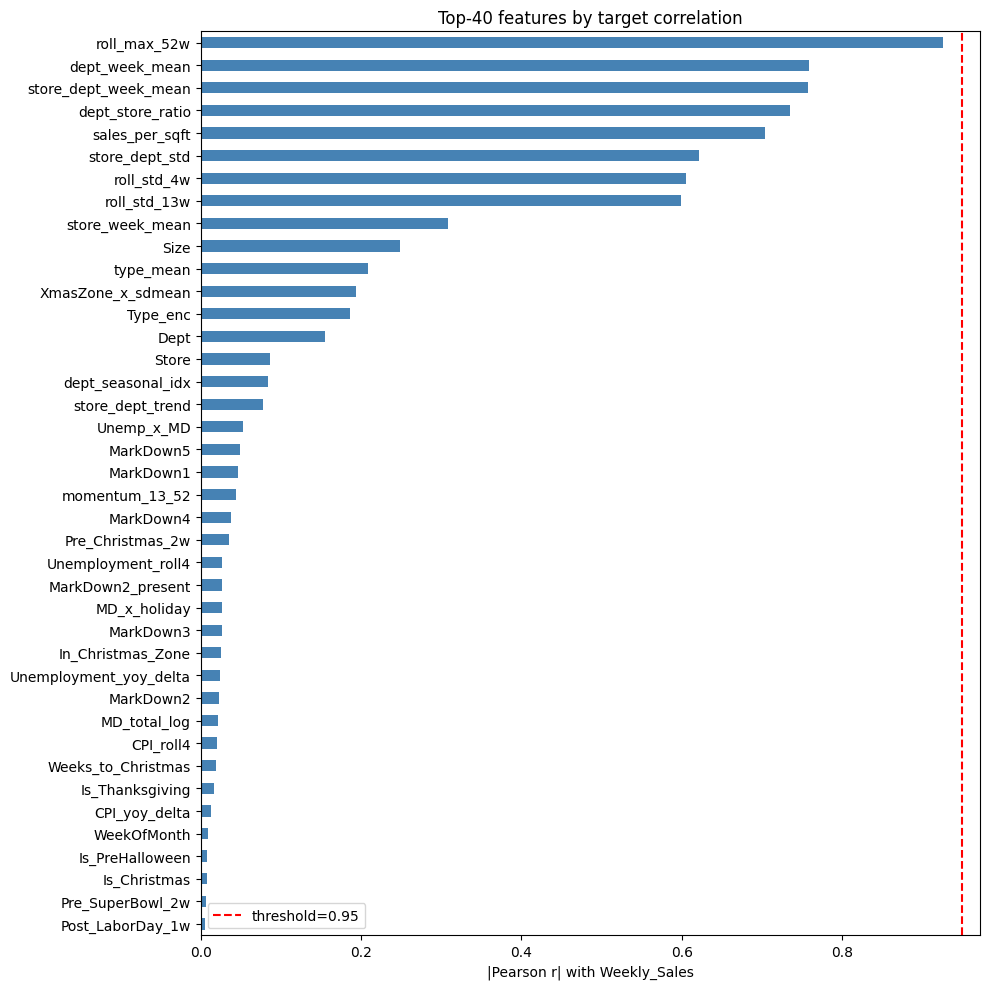

In [32]:
from sklearn.feature_selection import VarianceThreshold

X_tr_sel = df.loc[tr_mask, FEATURES].fillna(0)
y_tr_sel = df.loc[tr_mask, 'Weekly_Sales']

vt = VarianceThreshold(threshold=1e-4)
vt.fit(X_tr_sel)
low_var = [f for f, keep in zip(FEATURES, vt.get_support()) if not keep]
print(f"Low-variance removed: {len(low_var)} → {low_var}")
FEATURES = [f for f in FEATURES if f not in low_var]

corr_with_target = (
    X_tr_sel[FEATURES]
    .corrwith(y_tr_sel)
    .abs()
    .sort_values(ascending=False)
)
TARGET_CORR_THRESHOLD = 0.95
high_target_corr = corr_with_target[corr_with_target > TARGET_CORR_THRESHOLD].index.tolist()
print(f"\n|r| > {TARGET_CORR_THRESHOLD} vs target — review for leakage ({len(high_target_corr)}):")
for f in high_target_corr:
    print(f"  {f:45s}  r={corr_with_target[f]:.4f}")

LEAKY_HIGH_CORR = []
FEATURES = [f for f in FEATURES if f not in LEAKY_HIGH_CORR]

FINAL_CORR_THRESHOLD = 0.90
sample_sel = df.loc[tr_mask, FEATURES].sample(n=min(20_000, tr_mask.sum()), random_state=0).fillna(0)
corr_mat = sample_sel.corr().abs()
upper_sel = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
to_drop_sel = {p for col in upper_sel.columns for p in upper_sel.index[upper_sel[col] > FINAL_CORR_THRESHOLD]}
print(f"\nCollinear removed at |r| > {FINAL_CORR_THRESHOLD}: {len(to_drop_sel)}")
FEATURES = [f for f in FEATURES if f not in to_drop_sel]
print(f"\nFinal feature count: {len(FEATURES)}")

fig, ax = plt.subplots(figsize=(10, 10))
corr_with_target[FEATURES].sort_values().tail(40).plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('|Pearson r| with Weekly_Sales')
ax.set_title('Top-40 features by target correlation')
ax.axvline(TARGET_CORR_THRESHOLD, color='red', linestyle='--', label=f'threshold={TARGET_CORR_THRESHOLD}')
ax.legend()
plt.tight_layout()
plt.show()

In [33]:
X_tr   = df.loc[tr_mask,  FEATURES]
y_tr   = df.loc[tr_mask,  'Weekly_Sales']
X_val  = df.loc[val_mask, FEATURES]
y_val  = df.loc[val_mask, 'Weekly_Sales']
X_test = df.loc[te_mask,  FEATURES]

w_val = df.loc[val_mask, 'IsHoliday'].astype(float).map({1.0: 5.0, 0.0: 1.0})

print(f"X_tr   : {X_tr.shape}")
print(f"X_val  : {X_val.shape}")
print(f"X_test : {X_test.shape}")
print(f"Features: {len(FEATURES)}")

X_tr   : (397841, 67)
X_val  : (23729, 67)
X_test : (115064, 67)
Features: 67
